In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

import warnings
warnings.filterwarnings("ignore")

In [2]:
anime = pd.read_csv("C:\\Users\\gagan\\Downloads\\anime.csv")

print("Dataset Shape:", anime.shape)
anime.head()

Dataset Shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [4]:
anime.describe(include='all')

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Shi Wan Ge Leng Xiaohua,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [5]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [6]:
anime['genre'] = anime['genre'].fillna('Unknown')

anime['type'] = anime['type'].fillna('Unknown')

anime['rating'] = anime['rating'].fillna(
    anime['rating'].mean()
)

anime['episodes'] = anime['episodes'].replace(
    'Unknown',
    np.nan
)

anime['episodes'] = pd.to_numeric(
    anime['episodes'],
    errors='coerce'
)

anime['episodes'] = anime['episodes'].fillna(
    anime['episodes'].median()
)

anime.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

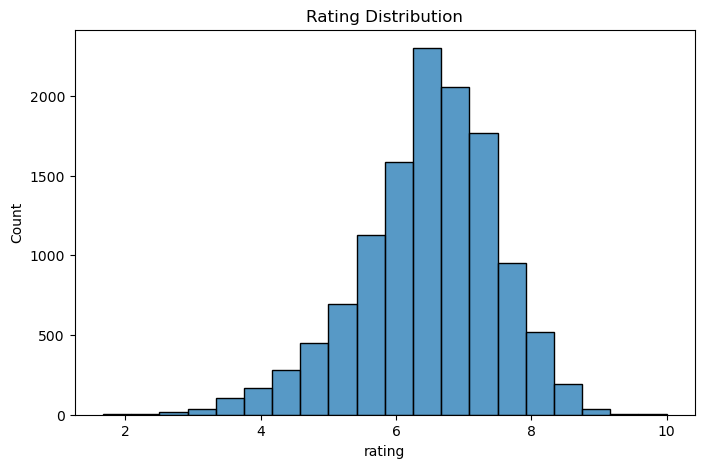

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(anime['rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

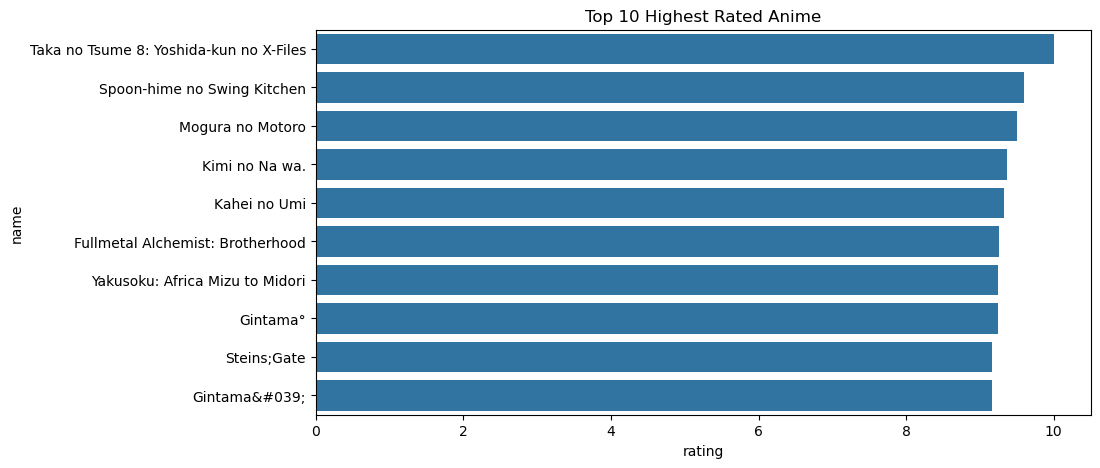

In [8]:
top10 = anime.sort_values(
    by='rating',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x='rating',
    y='name',
    data=top10
)

plt.title("Top 10 Highest Rated Anime")
plt.show()

In [9]:
tfidf = TfidfVectorizer(stop_words='english')

genre_matrix = tfidf.fit_transform(
    anime['genre']
)

genre_matrix.shape

(12294, 47)

In [10]:
scaler = MinMaxScaler()

numeric_features = scaler.fit_transform(
    anime[['rating','episodes','members']]
)

numeric_features

array([[9.24369748e-01, 0.00000000e+00, 1.97872202e-01],
       [9.11164466e-01, 3.46725371e-02, 7.82770102e-01],
       [9.09963986e-01, 2.75178866e-02, 1.12689267e-01],
       ...,
       [3.85354142e-01, 1.65107320e-03, 2.11063682e-04],
       [3.97358944e-01, 0.00000000e+00, 1.67667411e-04],
       [4.54981993e-01, 0.00000000e+00, 1.35120208e-04]], shape=(12294, 3))

In [11]:
feature_matrix = hstack(
    [genre_matrix, numeric_features]
)

feature_matrix.shape

(12294, 50)

In [12]:
cosine_sim = cosine_similarity(
    feature_matrix,
    feature_matrix
)

cosine_sim.shape

(12294, 12294)

In [13]:
def recommend_anime(anime_name,
                    threshold=0.50,
                    top_n=10):

    anime_name = anime_name.lower()

    match = anime[
        anime['name'].str.lower() == anime_name
    ]

    if match.empty:
        return "Anime Not Found"

    idx = match.index[0]

    scores = list(
        enumerate(cosine_sim[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:]

    recommendations = []

    for i, score in scores:

        if score >= threshold:

            recommendations.append(
                [
                    anime.iloc[i]['name'],
                    round(score,4)
                ]
            )

    return pd.DataFrame(
        recommendations,
        columns=[
            "Recommended Anime",
            "Similarity Score"
        ]
    ).head(top_n)

In [14]:
recommend_anime(
    "Naruto",
    threshold=0.50,
    top_n=10
)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [15]:
recommend_anime(
    "Death Note",
    threshold=0.50,
    top_n=10
)

,Recommended Anime,Similarity Score
0,Mirai Nikki (TV),0.9045
1,Mousou Dairinin,0.8384
2,Death Note Rewrite,0.8336
3,Higurashi no Naku Koro ni,0.8335
4,Higurashi no Naku Koro ni Kai,0.8277
5,Monster,0.7972
6,Another,0.7945
7,Zankyou no Terror,0.7941
8,Death Parade,0.7882
9,Mahou Shoujo Madoka★Magica,0.7811


In [16]:
recommend_anime(
    "Naruto",
    threshold=0.30,
    top_n=10
)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [17]:
recommend_anime(
    "Naruto",
    threshold=0.70,
    top_n=10
)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [18]:
print("Total Anime :", anime.shape[0])

print("Genre Features :",
      genre_matrix.shape[1])

print("Feature Matrix Shape :",
      feature_matrix.shape)

print("Cosine Similarity Matrix :",
      cosine_sim.shape)

Total Anime : 12294
Genre Features : 47
Feature Matrix Shape : (12294, 50)
Cosine Similarity Matrix : (12294, 12294)


In [19]:
print("""
CONCLUSION

The Anime Recommendation System was
successfully implemented using Cosine Similarity.

Features such as Genre, Rating,
Episodes and Members were used to
measure similarity between anime.

The system recommends anime that are
most similar to the selected anime.

Different threshold values were tested
to control the number of recommendations.

The model performs well for content-based
recommendation and can be improved using
collaborative filtering and hybrid methods.
""")


CONCLUSION

The Anime Recommendation System was
successfully implemented using Cosine Similarity.

Features such as Genre, Rating,
Episodes and Members were used to
measure similarity between anime.

The system recommends anime that are
most similar to the selected anime.

Different threshold values were tested
to control the number of recommendations.

The model performs well for content-based
recommendation and can be improved using
collaborative filtering and hybrid methods.



In [20]:
print("""
User-Based Collaborative Filtering:
Recommends items based on similar users.

Item-Based Collaborative Filtering:
Recommends items similar to those
already liked by the user.

User-Based -> User similarity
Item-Based -> Item similarity
""")


User-Based Collaborative Filtering:
Recommends items based on similar users.

Item-Based Collaborative Filtering:
Recommends items similar to those
already liked by the user.

User-Based -> User similarity
Item-Based -> Item similarity



In [21]:
print("""
Collaborative Filtering is a recommendation
technique that predicts user interests
using preferences of other users.

Steps:
1. Collect ratings
2. Calculate similarity
3. Predict preferences
4. Recommend items

Types:
1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering
""")


Collaborative Filtering is a recommendation
technique that predicts user interests
using preferences of other users.

Steps:
1. Collect ratings
2. Calculate similarity
3. Predict preferences
4. Recommend items

Types:
1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering



In [22]:
recommend_anime("Naruto", threshold=0.5, top_n=10)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [23]:
recommend_anime("Death Note", threshold=0.5, top_n=10)

,Recommended Anime,Similarity Score
0,Mirai Nikki (TV),0.9045
1,Mousou Dairinin,0.8384
2,Death Note Rewrite,0.8336
3,Higurashi no Naku Koro ni,0.8335
4,Higurashi no Naku Koro ni Kai,0.8277
5,Monster,0.7972
6,Another,0.7945
7,Zankyou no Terror,0.7941
8,Death Parade,0.7882
9,Mahou Shoujo Madoka★Magica,0.7811


In [24]:
recommend_anime("Naruto", threshold=0.3, top_n=10)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [25]:
recommend_anime("Naruto", threshold=0.7, top_n=10)

,Recommended Anime,Similarity Score
0,Naruto: Shippuuden,0.9915
1,Dragon Ball Z,0.9428
2,Dragon Ball,0.9159
3,Naruto: Shippuuden Movie 4 - The Lost Tower,0.9059
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.9056
5,Boruto: Naruto the Movie,0.9020
6,Naruto x UT,0.8845
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.8841
8,Dragon Ball Kai,0.8830
9,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.8821


In [26]:
print("Total Anime:", anime.shape[0])
print("Genre Features:", genre_matrix.shape[1])
print("Feature Matrix Shape:", feature_matrix.shape)
print("Cosine Similarity Shape:", cosine_sim.shape)

Total Anime: 12294
Genre Features: 47
Feature Matrix Shape: (12294, 50)
Cosine Similarity Shape: (12294, 12294)


In [27]:
print("""
Recommendation System Successfully Built

1. Dataset Loaded
2. Missing Values Handled
3. Features Extracted
4. Features Normalized
5. Cosine Similarity Applied
6. Recommendation Function Created
7. Threshold Values Tested

The model recommends anime based on
genre, rating, episodes and members.
""")


Recommendation System Successfully Built

1. Dataset Loaded
2. Missing Values Handled
3. Features Extracted
4. Features Normalized
5. Cosine Similarity Applied
6. Recommendation Function Created
7. Threshold Values Tested

The model recommends anime based on
genre, rating, episodes and members.

